In [1]:
import pandas as pd
d1=pd.read_csv("abtest.csv")

In [2]:
# 1. View the first few rows of the dataset
print(d1.head())  

# 2. Check the shape (number of rows × number of columns)
print("Shape:", d1.shape)

# 3. Check column names and data types
print(d1.info())

   user_id      group landing_page  time_spent_on_the_page converted  \
0   546592    control          old                    3.48        no   
1   546468  treatment          new                    7.13       yes   
2   546462  treatment          new                    4.40        no   
3   546567    control          old                    3.02        no   
4   546459  treatment          new                    4.75       yes   

  language_preferred  
0            Spanish  
1            English  
2            Spanish  
3             French  
4            Spanish  
Shape: (100, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    

In [3]:
# Check how many missing values each column has
print(d1.isnull().sum())

user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64


In [4]:
# Count how many duplicate rows exist
print("Number of duplicate rows:", d1.duplicated().sum())

# Optionally display the duplicate rows
print(d1[d1.duplicated()])

Number of duplicate rows: 0
Empty DataFrame
Columns: [user_id, group, landing_page, time_spent_on_the_page, converted, language_preferred]
Index: []


In [5]:
numeric_vars = d1.select_dtypes(include=['number'])
print("Numeric variables:")
print(numeric_vars.columns)

Numeric variables:
Index(['user_id', 'time_spent_on_the_page'], dtype='object')


In [6]:
categorical_vars = d1.select_dtypes(exclude=['number'])
print("Categorical variables:")
print(categorical_vars.columns)

Categorical variables:
Index(['group', 'landing_page', 'converted', 'language_preferred'], dtype='object')


Frequency of Converted vs Not Converted:
converted
yes    54
no     46
Name: count, dtype: int64 

Frequency of Landing Page Types:
landing_page
old    50
new    50
Name: count, dtype: int64 

Frequency of Preferred Language:
language_preferred
Spanish    34
French     34
English    32
Name: count, dtype: int64 

Landing Page vs Converted:
converted     no  yes
landing_page         
new           17   33
old           29   21 

Language vs Converted:
converted           no  yes
language_preferred         
English             11   21
French              19   15
Spanish             16   18 

Landing Page vs Language:
language_preferred  English  French  Spanish
landing_page                                
new                      16      17       17
old                      16      17       17 



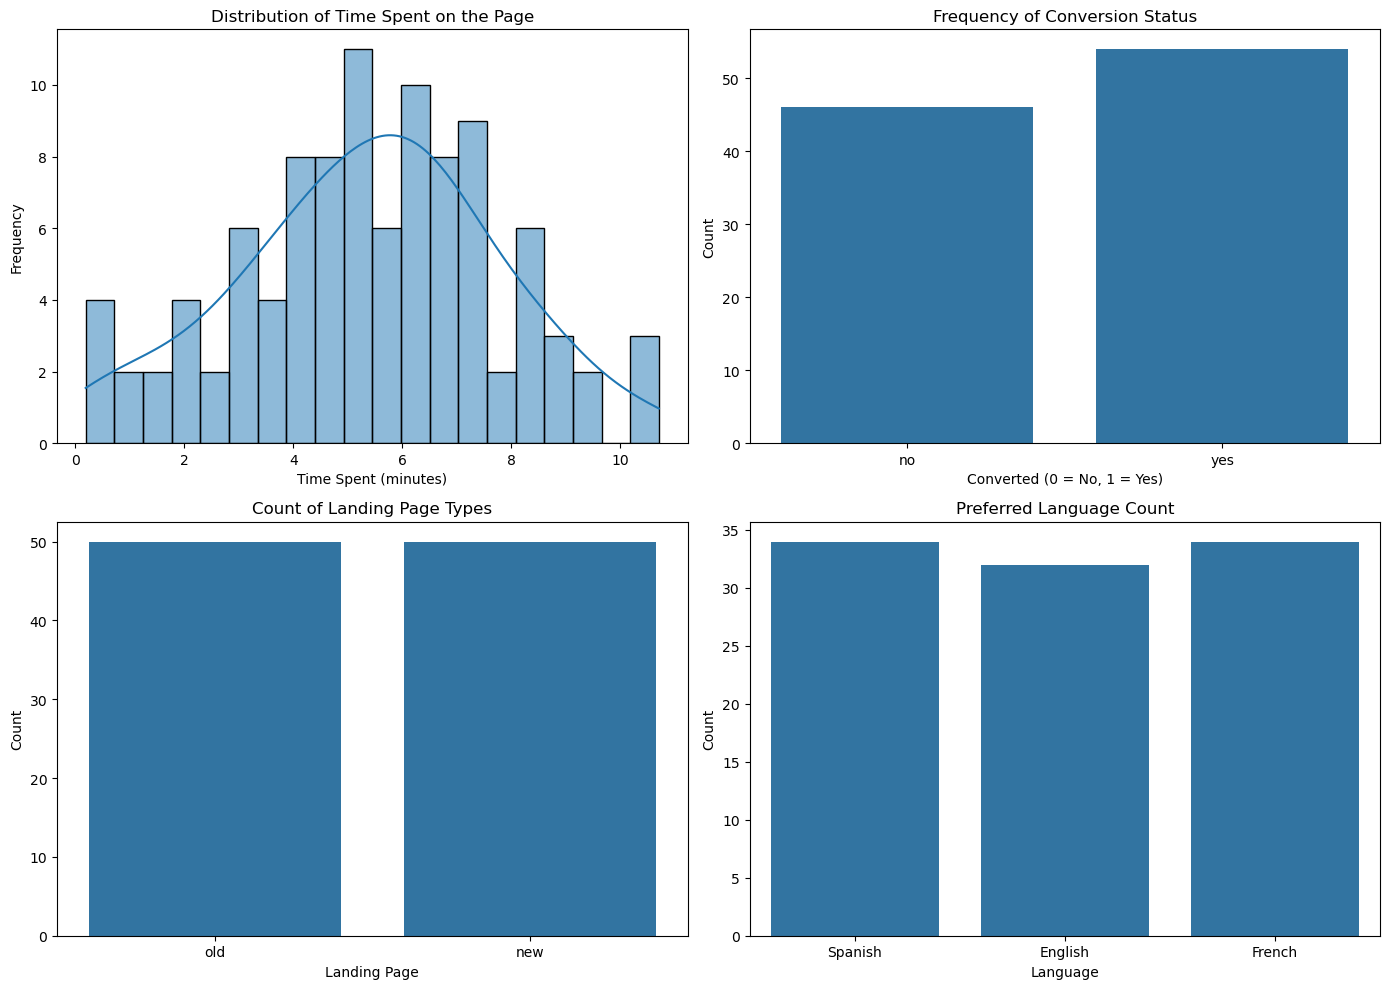

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1) Frequency tables (text output)
print("Frequency of Converted vs Not Converted:")
print(d1['converted'].value_counts(), "\n")

print("Frequency of Landing Page Types:")
print(d1['landing_page'].value_counts(), "\n")

print("Frequency of Preferred Language:")
print(d1['language_preferred'].value_counts(), "\n")

# 2) Cross‑tabulation tables
print("Landing Page vs Converted:")
print(pd.crosstab(d1['landing_page'], d1['converted']), "\n")

print("Language vs Converted:")
print(pd.crosstab(d1['language_preferred'], d1['converted']), "\n")

print("Landing Page vs Language:")
print(pd.crosstab(d1['landing_page'], d1['language_preferred']), "\n")

# 3) Combined plots (distribution + counts)
plt.figure(figsize=(14, 10))

# Distribution of time_spent_on_the_page
plt.subplot(2, 2, 1)
sns.histplot(data=d1, x='time_spent_on_the_page', kde=True, bins=20)
plt.title('Distribution of Time Spent on the Page')
plt.xlabel('Time Spent (minutes)')
plt.ylabel('Frequency')

# Count plot for conversion
plt.subplot(2, 2, 2)
sns.countplot(data=d1, x='converted')
plt.title('Frequency of Conversion Status')
plt.xlabel('Converted (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Count plot for landing page
plt.subplot(2, 2, 3)
sns.countplot(data=d1, x='landing_page')
plt.title('Count of Landing Page Types')
plt.xlabel('Landing Page')
plt.ylabel('Count')

# Count plot for language
plt.subplot(2, 2, 4)
sns.countplot(data=d1, x='language_preferred')
plt.title('Preferred Language Count')
plt.xlabel('Language')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

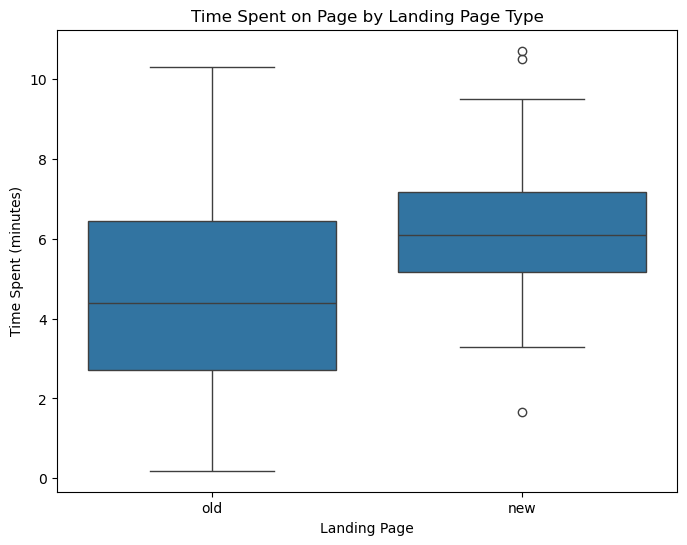

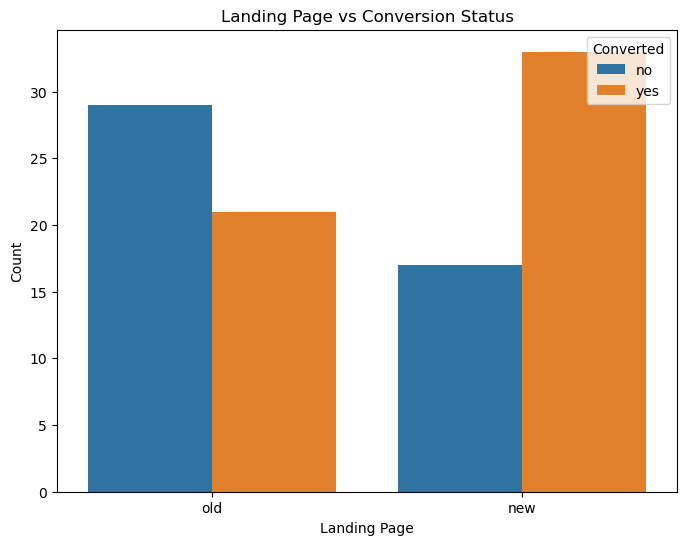

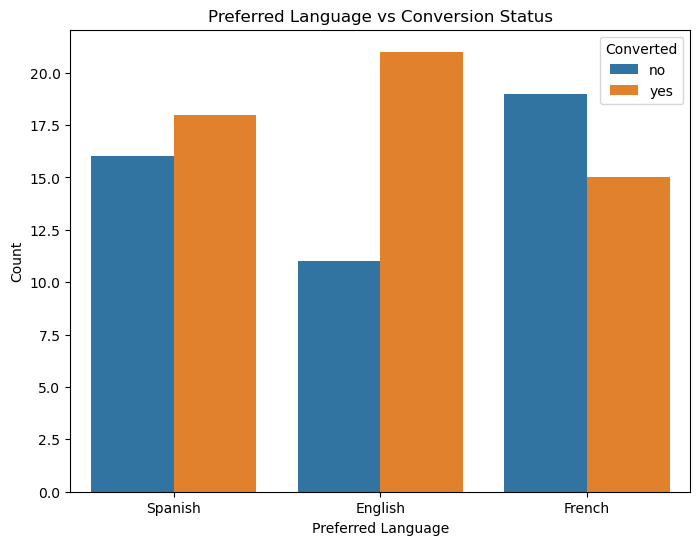

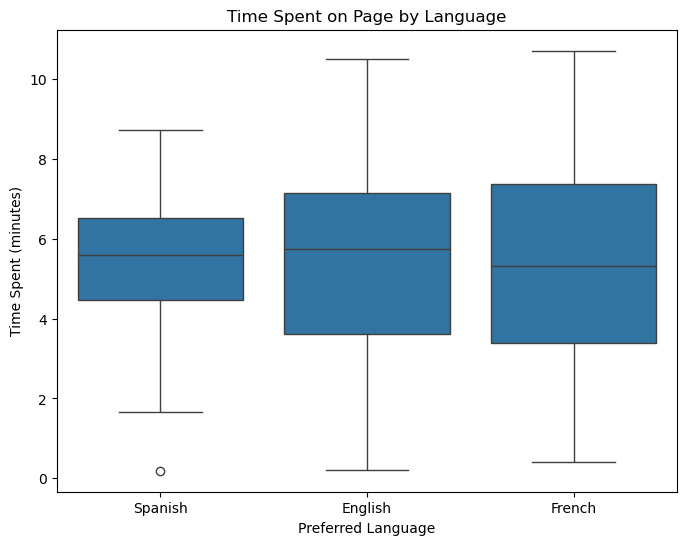

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) landing_page vs time_spent_on_the_page
plt.figure(figsize=(8, 6))
sns.boxplot(data=d1, x='landing_page', y='time_spent_on_the_page')
plt.title('Time Spent on Page by Landing Page Type')
plt.xlabel('Landing Page')
plt.ylabel('Time Spent (minutes)')
plt.show()

# 2) landing_page vs converted
plt.figure(figsize=(8, 6))
sns.countplot(data=d1, x='landing_page', hue='converted')
plt.title('Landing Page vs Conversion Status')
plt.xlabel('Landing Page')
plt.ylabel('Count')
plt.legend(title='Converted', loc='upper right')
plt.show()

# 3) language_preferred vs converted
plt.figure(figsize=(8, 6))
sns.countplot(data=d1, x='language_preferred', hue='converted')
plt.title('Preferred Language vs Conversion Status')
plt.xlabel('Preferred Language')
plt.ylabel('Count')
plt.legend(title='Converted', loc='upper right')
plt.show()

# 4) language_preferred vs time_spent_on_the_page
plt.figure(figsize=(8, 6))
sns.boxplot(data=d1, x='language_preferred', y='time_spent_on_the_page')
plt.title('Time Spent on Page by Language')
plt.xlabel('Preferred Language')
plt.ylabel('Time Spent (minutes)')
plt.show()

In [9]:
import pandas as pd

# 1) Landing Page vs Converted
print("Landing Page vs Converted — Frequency:")
landing_converted_freq = pd.crosstab(d1['landing_page'], d1['converted'], margins=True)
print(landing_converted_freq, "\n")

print("Landing Page vs Converted — Percent (%):")
landing_converted_pct = pd.crosstab(d1['landing_page'], d1['converted'], normalize='index') * 100
print(landing_converted_pct.round(2), "\n")

# 2) Preferred Language vs Converted
print("Language vs Converted — Frequency:")
lang_converted_freq = pd.crosstab(d1['language_preferred'], d1['converted'], margins=True)
print(lang_converted_freq, "\n")

print("Language vs Converted — Percent (%):")
lang_converted_pct = pd.crosstab(d1['language_preferred'], d1['converted'], normalize='index') * 100
print(lang_converted_pct.round(2), "\n")

# 3) Landing Page vs Preferred Language
print("Landing Page vs Language — Frequency:")
landing_lang_freq = pd.crosstab(d1['landing_page'], d1['language_preferred'], margins=True)
print(landing_lang_freq, "\n")

print("Landing Page vs Language — Percent (%):")
landing_lang_pct = pd.crosstab(d1['landing_page'], d1['language_preferred'], normalize='index') * 100
print(landing_lang_pct.round(2), "\n")

Landing Page vs Converted — Frequency:
converted     no  yes  All
landing_page              
new           17   33   50
old           29   21   50
All           46   54  100 

Landing Page vs Converted — Percent (%):
converted       no   yes
landing_page            
new           34.0  66.0
old           58.0  42.0 

Language vs Converted — Frequency:
converted           no  yes  All
language_preferred              
English             11   21   32
French              19   15   34
Spanish             16   18   34
All                 46   54  100 

Language vs Converted — Percent (%):
converted              no    yes
language_preferred              
English             34.38  65.62
French              55.88  44.12
Spanish             47.06  52.94 

Landing Page vs Language — Frequency:
language_preferred  English  French  Spanish  All
landing_page                                     
new                      16      17       17   50
old                      16      17       17   50
All 

In [10]:
# 1) Landing Page vs Converted — Combined Count + Row %
counts_lp_conv = pd.crosstab(d1['landing_page'], d1['converted'], margins=True)
pct_lp_conv = pd.crosstab(d1['landing_page'], d1['converted'], normalize='index') * 100

# Combine counts with percentages
combined_lp_conv = counts_lp_conv.copy().astype(str)
for col in pct_lp_conv.columns:
    combined_lp_conv[col] = counts_lp_conv[col].astype(str) + " (" + pct_lp_conv[col].round(2).astype(str) + "%)"

print("Landing Page vs Converted — Count (Row %):")
print(combined_lp_conv, "\n")


# 2) Language Preferred vs Converted — Combined Count + Row %
counts_lang_conv = pd.crosstab(d1['language_preferred'], d1['converted'], margins=True)
pct_lang_conv = pd.crosstab(d1['language_preferred'], d1['converted'], normalize='index') * 100

combined_lang_conv = counts_lang_conv.copy().astype(str)
for col in pct_lang_conv.columns:
    combined_lang_conv[col] = counts_lang_conv[col].astype(str) + " (" + pct_lang_conv[col].round(2).astype(str) + "%)"

print("Language vs Converted — Count (Row %):")
print(combined_lang_conv, "\n")


# 3) Landing Page vs Language Preferred — Combined Count + Row %
counts_lp_lang = pd.crosstab(d1['landing_page'], d1['language_preferred'], margins=True)
pct_lp_lang = pd.crosstab(d1['landing_page'], d1['language_preferred'], normalize='index') * 100

combined_lp_lang = counts_lp_lang.copy().astype(str)
for col in pct_lp_lang.columns:
    combined_lp_lang[col] = counts_lp_lang[col].astype(str) + " (" + pct_lp_lang[col].round(2).astype(str) + "%)"

print("Landing Page vs Language — Count (Row %):")
print(combined_lp_lang, "\n")

Landing Page vs Converted — Count (Row %):
converted             no         yes  All
landing_page                             
new           17 (34.0%)  33 (66.0%)   50
old           29 (58.0%)  21 (42.0%)   50
All                  NaN         NaN  100 

Language vs Converted — Count (Row %):
converted                    no          yes  All
language_preferred                               
English             11 (34.38%)  21 (65.62%)   32
French              19 (55.88%)  15 (44.12%)   34
Spanish             16 (47.06%)  18 (52.94%)   34
All                         NaN          NaN  100 

Landing Page vs Language — Count (Row %):
language_preferred     English      French     Spanish  All
landing_page                                               
new                 16 (32.0%)  17 (34.0%)  17 (34.0%)   50
old                 16 (32.0%)  17 (34.0%)  17 (34.0%)   50
All                        NaN         NaN         NaN  100 



In [11]:
pip install scipy statsmodels

Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from statsmodels.stats.proportion import proportions_ztest

# ————————
# 0) Prepare data
# Convert 'converted' from text ("yes"/"no") to numeric (1/0)
d1['converted_binary'] = d1['converted'].replace({'yes': 1, 'no': 0})

# ————————
# 1) Compare mean time spent: New vs Old landing page (one‑tailed two‑sample t‑test)
time_new = d1.loc[d1['landing_page'] == 'new', 'time_spent_on_the_page'].astype(float)
time_old = d1.loc[d1['landing_page'] == 'old', 'time_spent_on_the_page'].astype(float)

t_stat, p_val_time = ttest_ind(time_new, time_old, alternative='greater')
print("1) Time Spent: New vs Old Page")
print("   T‑statistic:", t_stat)
print("   P‑value    :", p_val_time, "\n")

# ————————
# 2) Compare conversion rates: New vs Old landing page (two‑proportion Z‑test)
conv_new = d1.loc[d1['landing_page'] == 'new', 'converted_binary'].sum()
conv_old = d1.loc[d1['landing_page'] == 'old', 'converted_binary'].sum()
n_new = d1.loc[d1['landing_page'] == 'new'].shape[0]
n_old = d1.loc[d1['landing_page'] == 'old'].shape[0]

counts = np.array([conv_new, conv_old])
nobs = np.array([n_new, n_old])

z_stat_conv, p_val_conv = proportions_ztest(counts, nobs, alternative='larger')
print("2) Conversion Rate: New vs Old Page")
print("   Z‑statistic:", z_stat_conv)
print("   P‑value    :", p_val_conv, "\n")

# ————————
# 3) Test independence: Preferred language vs conversion (Chi‑square test)
contingency_table = pd.crosstab(d1['language_preferred'], d1['converted_binary'])
chi2_stat, p_val_lang_conv, dof, expected = chi2_contingency(contingency_table)
print("3) Conversion vs Preferred Language")
print("   Chi2 Statistic:", chi2_stat)
print("   P‑value       :", p_val_lang_conv, "\n")

# ————————
# 4) Compare mean time spent on New page by language (one‑way ANOVA)
new_page_data = d1[d1['landing_page'] == 'new']
groups = [
    grp['time_spent_on_the_page'].astype(float).values
    for _, grp in new_page_data.groupby('language_preferred')
]

f_stat_anova, p_val_anova = f_oneway(*groups)
print("4) Time Spent on New Page by Language")
print("   F‑statistic:", f_stat_anova)
print("   P‑value    :", p_val_anova)

1) Time Spent: New vs Old Page
   T‑statistic: 3.7867702694199856
   P‑value    : 0.0001316123528095005 

2) Conversion Rate: New vs Old Page
   Z‑statistic: 2.4077170617153842
   P‑value    : 0.008026308204056278 

3) Conversion vs Preferred Language
   Chi2 Statistic: 3.0930306905370832
   P‑value       : 0.2129888748754345 

4) Time Spent on New Page by Language
   F‑statistic: 0.8543992770006822
   P‑value    : 0.43204138694325955


C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_14904\1919727601.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d1['converted_binary'] = d1['converted'].replace({'yes': 1, 'no': 0})


In [13]:
import pandas as pd

# Create a dictionary of test results
summary = {
    "Research Question": [
        "Time Spent: New vs Old Page",
        "Conversion Rate: New vs Old Page",
        "Conversion vs Preferred Language",
        "Time Spent on New Page by Language"
    ],
    "Test Used": [
        "Two-sample t-test",
        "Two-proportion Z-test",
        "Chi-square test",
        "One-way ANOVA"
    ],
    "Test Statistic": [
        round(t_stat, 3),
        round(z_stat_conv, 3),
        round(chi2_stat, 3),
        round(f_stat_anova, 3)
    ],
    "p-value": [
        round(p_val_time, 3),
        round(p_val_conv, 3),
        round(p_val_lang_conv, 3),
        round(p_val_anova, 3)
    ],
    "Decision (α=0.05)": [
        "Reject H0" if p_val_time < 0.05 else "Fail to reject H0",
        "Reject H0" if p_val_conv < 0.05 else "Fail to reject H0",
        "Reject H0" if p_val_lang_conv < 0.05 else "Fail to reject H0",
        "Reject H0" if p_val_anova < 0.05 else "Fail to reject H0"
    ],
    "Conclusion": [
        "Users spend more time on new page" if p_val_time < 0.05 else "No evidence that new page increases time",
        "Conversion rate higher on new page" if p_val_conv < 0.05 else "No evidence of higher conversion on new page",
        "Conversion depends on language" if p_val_lang_conv < 0.05 else "No evidence that conversion depends on language",
        "Time differs by language" if p_val_anova < 0.05 else "No evidence that time differs by language"
    ]
}

# Build DataFrame
summary_df = pd.DataFrame(summary)

# Display the summary table
print(summary_df)

                    Research Question              Test Used  Test Statistic  \
0         Time Spent: New vs Old Page      Two-sample t-test           3.787   
1    Conversion Rate: New vs Old Page  Two-proportion Z-test           2.408   
2    Conversion vs Preferred Language        Chi-square test           3.093   
3  Time Spent on New Page by Language          One-way ANOVA           0.854   

   p-value  Decision (α=0.05)                                       Conclusion  
0    0.000          Reject H0                Users spend more time on new page  
1    0.008          Reject H0               Conversion rate higher on new page  
2    0.213  Fail to reject H0  No evidence that conversion depends on language  
3    0.432  Fail to reject H0        No evidence that time differs by language  


In [14]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from statsmodels.stats.proportion import proportions_ztest

# Ensure 'converted' column is numeric (0/1)
d1['converted_binary'] = d1['converted'].replace({'yes':1, 'no':0})

# -----------------------------------------
# 1) Compare time spent (new vs old) — Two‑sample t‑test
time_new = d1[d1['landing_page']=='new']['time_spent_on_the_page'].astype(float)
time_old = d1[d1['landing_page']=='old']['time_spent_on_the_page'].astype(float)

t_stat_time, p_val_time = ttest_ind(time_new, time_old, alternative='greater')
print("1) Two‑sample t‑test (Time spent):")
print("   t-statistic:", t_stat_time)
print("   p-value    :", p_val_time, "\n")

# -----------------------------------------
# 2) Compare conversion rates (new vs old) — Two‑proportion Z‑test
conv_new = d1[d1['landing_page']=='new']['converted_binary'].sum()
conv_old = d1[d1['landing_page']=='old']['converted_binary'].sum()

n_new = d1[d1['landing_page']=='new'].shape[0]
n_old = d1[d1['landing_page']=='old'].shape[0]

counts = np.array([conv_new, conv_old])
nobs = np.array([n_new, n_old])

z_stat_conv, p_val_conv = proportions_ztest(counts, nobs, alternative='larger')
print("2) Two‑proportion Z‑test (Conversion rates):")
print("   z-statistic:", z_stat_conv)
print("   p-value    :", p_val_conv, "\n")

# -----------------------------------------
# 3) Conversion vs language — Chi‑square test
contingency_table = pd.crosstab(d1['language_preferred'], d1['converted_binary'])
chi2_stat, p_val_chi2, dof, expected = chi2_contingency(contingency_table)
print("3) Chi‑square test (Conversion vs Language):")
print("   chi2 statistic:", chi2_stat)
print("   p-value      :", p_val_chi2, "\n")

# -----------------------------------------
# 4) Time spent across languages — One‑way ANOVA
new_page_data = d1[d1['landing_page']=='new']
groups = [grp['time_spent_on_the_page'].astype(float).values
          for _, grp in new_page_data.groupby('language_preferred')]

f_stat_anova, p_val_anova = f_oneway(*groups)
print("4) One‑way ANOVA (Time spent by language on new page):")
print("   F-statistic:", f_stat_anova)
print("   p-value    :", p_val_anova)

1) Two‑sample t‑test (Time spent):
   t-statistic: 3.7867702694199856
   p-value    : 0.0001316123528095005 

2) Two‑proportion Z‑test (Conversion rates):
   z-statistic: 2.4077170617153842
   p-value    : 0.008026308204056278 

3) Chi‑square test (Conversion vs Language):
   chi2 statistic: 3.0930306905370832
   p-value      : 0.2129888748754345 

4) One‑way ANOVA (Time spent by language on new page):
   F-statistic: 0.8543992770006822
   p-value    : 0.43204138694325955


C:\Users\MAXWELL OJWANG\AppData\Local\Temp\ipykernel_14904\4074155817.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d1['converted_binary'] = d1['converted'].replace({'yes':1, 'no':0})


In [15]:
# Set significance level
alpha = 0.05

# 1) Time Spent (Two‑sample t‑test)
print("1) Time Spent: New vs Old Page")
print("   p‑value:", p_val_time)
if p_val_time <= alpha:
    print("   Result: Statistically significant → Reject H₀")
else:
    print("   Result: Not statistically significant → Fail to reject H₀")
print("\n")

# 2) Conversion Rates (Two‑proportion Z‑test)
print("2) Conversion Rate: New vs Old Page")
print("   p‑value:", p_val_conv)
if p_val_conv <= alpha:
    print("   Result: Statistically significant → Reject H₀")
else:
    print("   Result: Not statistically significant → Fail to reject H₀")
print("\n")

# 3) Conversion vs Language (Chi‑square test)
print("3) Conversion vs Preferred Language")
print("   p‑value:", p_val_lang_conv)
if p_val_lang_conv <= alpha:
    print("   Result: Statistically significant → Reject H₀")
else:
    print("   Result: Not statistically significant → Fail to reject H₀")
print("\n")

# 4) Time Spent by Language (One‑way ANOVA)
print("4) Time Spent on New Page by Language")
print("   p‑value:", p_val_anova)
if p_val_anova <= alpha:
    print("   Result: Statistically significant → Reject H₀")
else:
    print("   Result: Not statistically significant → Fail to reject H₀")

1) Time Spent: New vs Old Page
   p‑value: 0.0001316123528095005
   Result: Statistically significant → Reject H₀


2) Conversion Rate: New vs Old Page
   p‑value: 0.008026308204056278
   Result: Statistically significant → Reject H₀


3) Conversion vs Preferred Language
   p‑value: 0.2129888748754345
   Result: Not statistically significant → Fail to reject H₀


4) Time Spent on New Page by Language
   p‑value: 0.43204138694325955
   Result: Not statistically significant → Fail to reject H₀
